<a href="https://colab.research.google.com/github/Sebas2017/MasterAI-Ejercicios/blob/Semana2/Sesion2IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 2 — Datos, Librerías IA y Prompting Avanzado

**Módulo: Python para IA** | Máster en Inteligencia Artificial

## Objetivos de esta sesión

- Conocer **NumPy** y **Pandas**: las librerías fundamentales para datos en Python.
- Dominar técnicas de **prompting avanzado**: Chain of Thought, Role Prompting, System Prompts.
- Entender el **desarrollo agéntico**: qué son los agentes para desarrollo y cómo usar GitHub Copilot.
- Construir una **red neuronal con Keras** guiada por prompts.

> 💡 **Recuerda**: no necesitas memorizar la API de cada librería. Necesitas saber *qué hace* y *cómo pedírselo a la IA*.

### Contexto: de los fundamentos al ecosistema real

En la Sesión 1 aprendimos los fundamentos de Python y los principios del prompting. En esta sesión damos el salto al **ecosistema real de la IA**: las librerías que usaréis a diario (NumPy, Pandas, Keras), las técnicas de prompting que marcan la diferencia entre un prompt mediocre y uno profesional, y las herramientas de desarrollo asistido por IA que están transformando la industria.

Al final de esta sesión seréis capaces de:
1. Manipular datos numéricos y tabulares con NumPy y Pandas.
2. Escribir prompts avanzados que producen código de calidad profesional.
3. Usar GitHub Copilot como asistente de desarrollo.
4. Construir y entrenar vuestra primera red neuronal.

---
# Bloque 1 — NumPy y Pandas Express (15 min)

Estas dos librerías son la **base de todo el ecosistema de datos y Machine Learning en Python**. Prácticamente cualquier proyecto de IA las usa, directa o indirectamente:

- **NumPy** maneja los arrays numéricos internos de TensorFlow, PyTorch, Scikit-learn...
- **Pandas** es la herramienta estándar para cargar, limpiar y explorar datos antes de alimentar un modelo.

El objetivo de este bloque no es que dominéis cada función — eso lo haréis progresivamente a lo largo del Máster. El objetivo es que entendáis **qué hacen** y **cuándo usarlas**, para que podáis pedirle a la IA operaciones concretas: *"calcula la media por grupo"*, *"normaliza esta columna"*, *"reshapea este array a 3 dimensiones"*.

## NumPy — La Base Numérica

**NumPy** (Numerical Python) es la librería fundamental para cálculo numérico en Python. Proporciona **arrays multidimensionales eficientes** y **operaciones vectorizadas** que son órdenes de magnitud más rápidas que los bucles nativos de Python.

### ¿Por qué no usar listas normales de Python?

Una lista de Python es muy flexible (puede mezclar tipos: `[1, "hola", True]`), pero esa flexibilidad tiene un coste: es **lenta para cálculos numéricos**. NumPy resuelve esto con arrays que:

- Almacenan datos del **mismo tipo** (todos `float`, todos `int`...) en memoria contigua.
- Permiten **operaciones vectorizadas**: en vez de un bucle `for` para sumar dos arrays, NumPy lo hace internamente en C, miles de veces más rápido.
- Soportan **broadcasting**: operaciones entre arrays de diferentes tamaños se resuelven automáticamente.

### Conceptos clave — Dimensiones de arrays

En el mundo de la IA, trabajaréis constantemente con arrays de diferentes dimensiones. Es crucial entender la terminología:

| Concepto | Dimensiones | Ejemplo | En IA se usa para... |
|----------|-------------|---------|---------------------|
| **Scalar** | 0D | `5` | Un valor individual (loss, accuracy) |
| **Vector** | 1D | `[1, 2, 3]` | Una muestra de features, embeddings |
| **Matriz** | 2D | `[[1,2],[3,4]]` | Dataset tabular, pesos de una capa |
| **Tensor 3D** | 3D | Cubo de números | Secuencias (texto), imágenes en escala de grises |
| **Tensor 4D** | 4D | Batch de imágenes | Batch de imágenes RGB (batch, alto, ancho, canales) |

El término **"shape"** describe las dimensiones de un array. Por ejemplo, `shape=(60000, 28, 28)` significa 60.000 imágenes de 28×28 píxeles — exactamente lo que veremos con el dataset MNIST más adelante.

> 🤖 **Para el prompting**: cuando trabajes con datos numéricos, especifica siempre el shape esperado: *"recibe un array de shape (n, 3) donde cada fila es un punto 3D"*.

In [ ]:
import numpy as np

# Crear arrays
vector = np.array([1, 2, 3, 4, 5])
matriz = np.array([[1, 2, 3], [4, 5, 6]])
tensor_3d = np.random.randn(2, 3, 4)  # 2 matrices de 3x4

print(f"Vector: {vector} → shape: {vector.shape}")
print(f"Matriz: {matriz} → shape: {matriz.shape}")
print(f"Tensor 3D shape: {tensor_3d.shape}")

# Operaciones vectorizadas (sin bucles!)
print(f"Vector * 2: {vector * 2}")
print(f"Vector ** 2: {vector ** 2}")
print(f"Media: {vector.mean():.1f}")
print(f"Suma: {vector.sum()}")

# Crear arrays especiales
print(f"Zeros: {np.zeros(5)}")
print(f"Rango: {np.arange(0, 10, 2)}")
print(f"Linspace: {np.linspace(0, 1, 5)}")

# Broadcasting — operar arrays de diferente tamaño
print(f"Matriz + 10: {matriz + 10}")

Vector: [1 2 3 4 5] → shape: (5,)
Matriz: [[1 2 3]
 [4 5 6]] → shape: (2, 3)
Tensor 3D shape: (2, 3, 4)
Vector * 2: [ 2  4  6  8 10]
Vector ** 2: [ 1  4  9 16 25]
Media: 3.0
Suma: 15
Zeros: [0. 0. 0. 0. 0.]
Rango: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]
Matriz + 10: [[11 12 13]
 [14 15 16]]


## Pandas — DataFrames para todo

**Pandas** es como una hoja de cálculo de Excel potenciada con Python. La estructura central es el **DataFrame**: una tabla con filas y columnas nombradas donde cada columna puede tener un tipo diferente (números, texto, fechas, booleanos...).

### ¿Por qué Pandas y no Excel?

- **Escala**: Excel empieza a fallar con más de 100.000 filas. Pandas maneja millones sin problema.
- **Reproducibilidad**: un script de Pandas se puede ejecutar miles de veces con los mismos resultados. En Excel, los pasos manuales no se registran.
- **Integración**: Pandas se conecta directamente con bases de datos, APIs, archivos CSV/JSON/Parquet, y con todo el ecosistema de ML (Scikit-learn, TensorFlow...).
- **Automatización**: puedes encadenar operaciones complejas en pocas líneas de código.

### Operaciones que usaréis constantemente

| Operación | Método | Para qué |
|-----------|--------|----------|
| Cargar datos | `pd.read_csv()`, `pd.read_json()` | Leer archivos |
| Inspeccionar | `.head()`, `.info()`, `.describe()` | Entender los datos |
| Filtrar | `df[df["col"] > valor]` | Seleccionar filas que cumplan condiciones |
| Agrupar | `.groupby("col").mean()` | Estadísticas por grupo |
| Ordenar | `.sort_values("col")` | Reordenar filas |
| Añadir columna | `df["nueva"] = ...` | Crear variables calculadas |
| Eliminar | `.drop(columns=["col"])` | Quitar columnas innecesarias |
| Valores nulos | `.isna()`, `.fillna()`, `.dropna()` | Gestionar datos faltantes |

> 💡 **No memoriréis todo esto** — Pandas tiene cientos de métodos. Lo importante es saber qué operaciones son posibles para poder pedírselas a Gemini: *"agrupa por categoría y calcula la media y desviación estándar del precio"*.

In [ ]:
import pandas as pd

# Crear DataFrame desde diccionario
datos = {
    "nombre": ["Ana", "Luis", "María", "Pedro", "Sara"],
    "edad": [22, 25, 23, 28, 21],
    "nota": [8.5, 7.2, 9.1, 6.8, 8.9],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla", "Barcelona"]
}
df = pd.DataFrame(datos)
print("DataFrame completo:")
print(df)
print(f"Shape: {df.shape}")  # (filas, columnas)

DataFrame completo:
  nombre  edad  nota     ciudad
0    Ana    22   8.5     Madrid
1   Luis    25   7.2  Barcelona
2  María    23   9.1     Madrid
3  Pedro    28   6.8    Sevilla
4   Sara    21   8.9  Barcelona
Shape: (5, 4)


In [ ]:
# Operaciones esenciales de Pandas

# 1. Estadísticas rápidas
print("=== Estadísticas ===")
print(df.describe())

# 2. Filtrado
print("=== Notas >= 8 ===")
print(df[df["nota"] >= 8])

# 3. Groupby
print("=== Media por ciudad ===")
print(df.groupby("ciudad")["nota"].mean())

# 4. Ordenar
print("=== Ordenado por nota (descendente) ===")
print(df.sort_values("nota", ascending=False))

# 5. Añadir columna calculada
df["aprobado"] = df["nota"] >= 5
print("=== Con columna aprobado ===")
print(df)

=== Estadísticas ===
            edad      nota
count   5.000000  5.000000
mean   23.800000  8.100000
std     2.774887  1.036822
min    21.000000  6.800000
25%    22.000000  7.200000
50%    23.000000  8.500000
75%    25.000000  8.900000
max    28.000000  9.100000
=== Notas >= 8 ===
  nombre  edad  nota     ciudad
0    Ana    22   8.5     Madrid
2  María    23   9.1     Madrid
4   Sara    21   8.9  Barcelona
=== Media por ciudad ===
ciudad
Barcelona    8.05
Madrid       8.80
Sevilla      6.80
Name: nota, dtype: float64
=== Ordenado por nota (descendente) ===
  nombre  edad  nota     ciudad
2  María    23   9.1     Madrid
4   Sara    21   8.9  Barcelona
0    Ana    22   8.5     Madrid
1   Luis    25   7.2  Barcelona
3  Pedro    28   6.8    Sevilla
=== Con columna aprobado ===
  nombre  edad  nota     ciudad  aprobado
0    Ana    22   8.5     Madrid      True
1   Luis    25   7.2  Barcelona      True
2  María    23   9.1     Madrid      True
3  Pedro    28   6.8    Sevilla      True
4   S

### 🛠️ Ejercicio — Análisis con Gemini

Pide a Gemini:

> *"Genera un DataFrame de Pandas con datos de 10 productos (nombre, categoría, precio, stock) y realiza un análisis exploratorio: estadísticas descriptivas, precio medio por categoría, productos con stock bajo (<5), y ordena por precio descendente."*

Pega el resultado y ejecútalo:

In [ ]:
# Pega aquí el código generado por Gemini para el análisis de productos


In [ ]:
import pandas as pd
import numpy as np

# Generar un DataFrame de Pandas con 10 productos
datos_productos = {
    "nombre": [f"Producto {i}" for i in range(1, 11)],
    "categoria": np.random.choice(["Electrónica", "Hogar", "Alimentos", "Libros"], size=10),
    "precio": np.round(np.random.uniform(10.0, 500.0, size=10), 2),
    "stock": np.random.randint(0, 20, size=10)
}
productos_df = pd.DataFrame(datos_productos)

print("DataFrame de Productos:")
print(productos_df)
print("\n")

# 1. Estadísticas descriptivas
print("Estadísticas Descriptivas:")
print(productos_df.describe())
print("\n")

# 2. Precio medio por categoría
print("Precio Medio por Categoría:")
print(productos_df.groupby("categoria")["precio"].mean())
print("\n")

# 3. Productos con stock bajo (<5)
print("Productos con Stock Bajo (<5):")
print(productos_df[productos_df["stock"] < 5])
print("\n")

# 4. Ordenar por precio descendente
print("Productos Ordenados por Precio (Descendente):")
print(productos_df.sort_values("precio", ascending=False))

DataFrame de Productos:
        nombre    categoria  precio  stock
0   Producto 1    Alimentos  307.10     15
1   Producto 2       Libros  149.30     12
2   Producto 3        Hogar  106.06     11
3   Producto 4  Electrónica  156.48     15
4   Producto 5    Alimentos  382.07      5
5   Producto 6  Electrónica  347.79     16
6   Producto 7  Electrónica  386.30      7
7   Producto 8  Electrónica  255.31      5
8   Producto 9  Electrónica  113.18      1
9  Producto 10       Libros   37.29      3


Estadísticas Descriptivas:
           precio      stock
count   10.000000  10.000000
mean   224.088000   9.000000
std    127.247706   5.477226
min     37.290000   1.000000
25%    122.210000   5.000000
50%    205.895000   9.000000
75%    337.617500  14.250000
max    386.300000  16.000000


Precio Medio por Categoría:
categoria
Alimentos      344.585
Electrónica    251.812
Hogar          106.060
Libros          93.295
Name: precio, dtype: float64


Productos con Stock Bajo (<5):
        nombre    c

---
# Bloque 2 — Prompting Avanzado para Desarrollo (25 min)

En la Sesión 1 vimos los fundamentos del prompting: instrucción clara, contexto, especificaciones, restricciones y ejemplos. Ahora vamos a ver **técnicas avanzadas** que provienen de la investigación en Prompt Engineering y que os permitirán generar código significativamente mejor.

### ¿Por qué importan estas técnicas?

La diferencia entre un prompt básico y uno con técnicas avanzadas es similar a la diferencia entre pedirle a alguien *"hazme una casa"* vs darle unos **planos detallados con especificaciones**. Los modelos de lenguaje son extremadamente sensibles a la forma en que les planteas el problema: un pequeño cambio en el prompt puede cambiar completamente la calidad y la estructura del código generado.

Las técnicas que vamos a ver (Chain of Thought, Role Prompting, System Prompts) son las mismas que usan internamente herramientas como GitHub Copilot, Cursor y otros asistentes de codificación para obtener resultados óptimos.

## Técnicas Avanzadas de Prompting

### 1. Chain of Thought (CoT) — Razonamiento paso a paso

**Chain of Thought** es una de las técnicas más investigadas y efectivas en la literatura de prompting (Wei et al., 2022). La idea es simple pero poderosa: **pedir al modelo que razone antes de dar la respuesta final**.

¿Por qué funciona? Los modelos de lenguaje generan texto token a token. Cuando les pides que "piensen en voz alta", el razonamiento intermedio les proporciona contexto adicional que mejora la calidad de la respuesta final. Es como la diferencia entre resolver un examen de cabeza vs escribir los pasos intermedios.

```
❌ Prompt sin CoT:
"Crea una función que encuentre el camino más corto en un grafo"

✅ Prompt con CoT:
"Necesito encontrar el camino más corto en un grafo con pesos positivos.
 Primero, explica qué algoritmo es más adecuado y por qué.
 Luego, describe los pasos del algoritmo en pseudocódigo.
 Finalmente, implementa el algoritmo en Python con type hints."
```

El resultado con CoT será mucho más robusto: la IA elegirá Dijkstra (o A*), explicará su razonamiento, y el código resultante será más correcto porque ha "pensado" en la estructura antes de escribir.

### 2. Role Prompting — Asignar un rol al modelo

Al dar un **rol** al modelo, cambias su "perspectiva" y el nivel de detalle, terminología y estilo de su respuesta. Es especialmente útil cuando necesitas código con un nivel de calidad específico:

```
✅ "Eres un desarrollador Python senior con 10 años de experiencia en data science.
    Revisa este código y sugiere mejoras siguiendo las mejores prácticas:
    PEP 8, manejo de errores, eficiencia y legibilidad."
```

Otros roles útiles:
- *"Eres un experto en seguridad informática — revisa este código en busca de vulnerabilidades"*
- *"Eres un profesor de Python que explica a principiantes — explica este código paso a paso"*
- *"Eres un ingeniero de MLOps — convierte este notebook en un script de producción"*

### 3. System Prompt — Instrucciones generales persistentes

En las APIs de LLMs (lo veremos con Gemini en la Sesión 3), puedes definir un **system prompt** que establece el comportamiento general del modelo para toda la conversación. Es como darle un "briefing" antes de empezar:

```
System: "Eres un asistente de programación Python especializado en IA.
         Siempre incluye type hints y docstrings estilo Google.
         Si el usuario no especifica manejo de errores, inclúyelo igualmente.
         Responde siempre en español."
```

El system prompt es lo que diferencia a un chatbot genérico de uno especializado. Herramientas como GitHub Copilot usan system prompts enormes internamente para que el modelo se comporte como un asistente de desarrollo.

> 💡 **En Colab**: Gemini no expone directamente el system prompt, pero puedes simular el efecto incluyendo las instrucciones al inicio de tu conversación: *"A partir de ahora, siempre que me generes código, incluye type hints y tests"*.

## Prompting para Tareas Específicas

Según el tipo de tarea que necesites, el prompt debe tener una estructura ligeramente diferente. Aquí tenéis plantillas para las tareas más comunes en desarrollo:

### 🔨 Generar código desde cero

La clave es ser **lo más específico posible** con los inputs, outputs y restricciones:

```
"Crea una clase Python `GestorInventario` que:
- Almacene productos como diccionarios {nombre, precio, stock}
- Tenga métodos: agregar_producto, eliminar_producto, buscar_producto, actualizar_stock
- Valide que precio y stock no sean negativos
- Tenga un método resumen() que devuelva estadísticas del inventario
- Use type hints y docstrings"
```

### 🐛 Debugging — Encontrar y corregir errores

Para debugging, proporciona siempre tres cosas: el **código**, el **error**, y qué **esperabas** que ocurriera:

```
"Tengo este error al ejecutar mi código:
[pega el traceback completo]

El código es:
[pega el código relevante]

Esperaba que devolviera X pero en su lugar hace Y.
Explica por qué ocurre el error y cómo solucionarlo."
```

### 🔄 Refactoring — Mejorar código existente

Al refactorizar, especifica **qué quieres mejorar** (legibilidad, eficiencia, modularidad) y **qué no debe cambiar** (la interfaz pública, los tests):

```
"Refactoriza este código para que sea más legible y eficiente.
Mantén la misma interfaz pública (mismos nombres de funciones y parámetros).
Explica cada cambio que hagas y por qué.


[pega el código]"
```

### 📝 Documentación y tests

```
"Para el siguiente código, genera:
1. Docstrings estilo Google para cada función y clase.
2. Al menos 3 tests unitarios con pytest que cubran: caso normal, caso límite y caso de error.

[pega el código]"
```

> 🔑 **Patrón general**: cuanto más contexto des sobre tu intención, mejores serán los resultados. *"Quiero optimizar esta función porque se ejecuta 10.000 veces por segundo en producción"* produce resultados muy diferentes a *"optimiza esto"*.

## 🛠️ Ejercicio Guiado — Crear una Clase con Prompting Iterativo

Vamos a crear una clase `GestorInventario` completa usando prompting paso a paso. Sigue estas instrucciones con Gemini:

**Iteración 1** — Estructura básica:
> *"Crea una clase `GestorInventario` en Python con un constructor que inicialice una lista vacía de productos"*

**Iteración 2** — Añadir productos:
> *"Añade un método `agregar_producto(nombre, precio, stock)` que añada un diccionario a la lista. Valida que precio y stock sean positivos."*

**Iteración 3** — Búsqueda y eliminación:
> *"Añade métodos `buscar_producto(nombre)` que devuelva el producto o None, y `eliminar_producto(nombre)` que lo elimine si existe."*

**Iteración 4** — Resumen estadístico:
> *"Añade un método `resumen()` que devuelva: número de productos, valor total del inventario (precio*stock por producto), producto más caro y producto con menos stock."*

**Iteración 5** — Type hints y docstrings:
> *"Añade type hints a todos los métodos y docstrings estilo Google. Además añade un método `__repr__` representativo."*

In [1]:
class GestorInventario:
    """Gestiona un inventario de productos.

    Attributes:
        productos: Lista de diccionarios con los productos del inventario.
    """

    def __init__(self) -> None:
        """Inicializa el gestor con una lista vacía de productos."""
        self.productos: list[dict] = []

    def agregar_producto(self, nombre: str, precio: float, stock: int) -> None:
        """Añade un producto al inventario.

        Args:
            nombre: Nombre del producto.
            precio: Precio unitario (debe ser positivo).
            stock: Cantidad en stock (debe ser no negativo).

        Raises:
            ValueError: Si precio no es positivo o stock es negativo.
        """
        if precio <= 0 or stock < 0:
            raise ValueError("El precio debe ser positivo y el stock no puede ser negativo.")
        self.productos.append({"nombre": nombre, "precio": precio, "stock": stock})

    def buscar_producto(self, nombre: str) -> dict | None:
        """Busca un producto por nombre (ignorando mayúsculas/minúsculas).

        Args:
            nombre: Nombre del producto a buscar.

        Returns:
            El diccionario del producto si se encuentra, None en caso contrario.
        """
        for p in self.productos:
            if p["nombre"].lower() == nombre.lower():
                return p
        return None

    def eliminar_producto(self, nombre: str) -> bool:
        """Elimina un producto del inventario por nombre.

        Args:
            nombre: Nombre del producto a eliminar.

        Returns:
            True si el producto fue eliminado, False si no se encontró.
        """
        producto = self.buscar_producto(nombre)
        if producto:
            self.productos.remove(producto)
            return True
        return False

    def resumen(self) -> dict:
        """Genera un resumen estadístico del inventario.

        Returns:
            Un diccionario con el número total de productos, el valor total del
            inventario, el nombre del producto más caro y el del producto con menos stock.
            Devuelve valores predeterminados si el inventario está vacío.
        """
        if not self.productos:
            return {"total_productos": 0, "valor_total": 0, "mas_caro": None, "menos_stock": None}

        valor_total = sum(p["precio"] * p["stock"] for p in self.productos)
        mas_caro = max(self.productos, key=lambda p: p["precio"])
        menos_stock = min(self.productos, key=lambda p: p["stock"])

        return {
            "total_productos": len(self.productos),
            "valor_total": round(valor_total, 2),
            "mas_caro": mas_caro["nombre"],
            "menos_stock": menos_stock["nombre"]
        }

    def __repr__(self) -> str:
        """Representación en cadena del objeto GestorInventario.

        Returns:
            Una cadena que indica la cantidad de productos en el inventario.
        """
        return f"GestorInventario({len(self.productos)} productos)"


# --- Código de prueba (el mismo que ya tenías) ---
inventario = GestorInventario()
print(f"Inventario inicial: {inventario.productos}")
inventario.agregar_producto("Laptop", 1200.00, 10)
inventario.agregar_producto("Mouse", 25.00, 50)
inventario.agregar_producto("Teclado", 79.99, 15)
inventario.agregar_producto("Monitor", 349.99, 3)
print(f"Inventario después de añadir productos: {inventario.productos}")

# Prueba de buscar_producto
producto_buscado = inventario.buscar_producto("Laptop")
print(f"Producto buscado 'Laptop': {producto_buscado}")

producto_no_existente = inventario.buscar_producto("Teclado")
print(f"Producto buscado 'Teclado': {producto_no_existente}")

# Prueba de eliminar_producto
print(f"Inventario antes de eliminar: {inventario.productos}")
eliminado = inventario.eliminar_producto("Mouse")
print(f"'Mouse' eliminado: {eliminado}")
print(f"Inventario después de eliminar 'Mouse': {inventario.productos}")

eliminado_no_existente = inventario.eliminar_producto("Teclado")
print(f"'Teclado' eliminado: {eliminado_no_existente}")
print(f"Inventario después de intentar eliminar 'Teclado': {inventario.productos}")

# Prueba de resumen
print(f"\nResumen del inventario: {inventario.resumen()}")

# Prueba de __repr__
print(f"\nRepresentación del inventario: {inventario}")

Inventario inicial: []
Inventario después de añadir productos: [{'nombre': 'Laptop', 'precio': 1200.0, 'stock': 10}, {'nombre': 'Mouse', 'precio': 25.0, 'stock': 50}, {'nombre': 'Teclado', 'precio': 79.99, 'stock': 15}, {'nombre': 'Monitor', 'precio': 349.99, 'stock': 3}]
Producto buscado 'Laptop': {'nombre': 'Laptop', 'precio': 1200.0, 'stock': 10}
Producto buscado 'Teclado': {'nombre': 'Teclado', 'precio': 79.99, 'stock': 15}
Inventario antes de eliminar: [{'nombre': 'Laptop', 'precio': 1200.0, 'stock': 10}, {'nombre': 'Mouse', 'precio': 25.0, 'stock': 50}, {'nombre': 'Teclado', 'precio': 79.99, 'stock': 15}, {'nombre': 'Monitor', 'precio': 349.99, 'stock': 3}]
'Mouse' eliminado: True
Inventario después de eliminar 'Mouse': [{'nombre': 'Laptop', 'precio': 1200.0, 'stock': 10}, {'nombre': 'Teclado', 'precio': 79.99, 'stock': 15}, {'nombre': 'Monitor', 'precio': 349.99, 'stock': 3}]
'Teclado' eliminado: True
Inventario después de intentar eliminar 'Teclado': [{'nombre': 'Laptop', 'prec

In [2]:
# Pega aquí el resultado de tu prompting iterativo

# Este es un ejemplo de lo que debería salir al final:
class GestorInventario:
    """Gestiona un inventario de productos.

    Attributes:
        productos: Lista de diccionarios con los productos del inventario.
    """

    def __init__(self) -> None:
        """Inicializa el gestor con una lista vacía de productos."""
        self.productos: list[dict] = []

    def agregar_producto(self, nombre: str, precio: float, stock: int) -> None:
        """Añade un producto al inventario.

        Args:
            nombre: Nombre del producto.
            precio: Precio unitario (debe ser positivo).
            stock: Cantidad en stock (debe ser positivo).

        Raises:
            ValueError: Si precio o stock no son positivos.
        """
        if precio <= 0 or stock < 0:
            raise ValueError("Precio debe ser positivo y stock no negativo")
        self.productos.append({"nombre": nombre, "precio": precio, "stock": stock})

    def buscar_producto(self, nombre: str) -> dict | None:
        """Busca un producto por nombre."""
        for p in self.productos:
            if p["nombre"].lower() == nombre.lower():
                return p
        return None

    def eliminar_producto(self, nombre: str) -> bool:
        """Elimina un producto por nombre. Devuelve True si se eliminó."""
        producto = self.buscar_producto(nombre)
        if producto:
            self.productos.remove(producto)
            return True
        return False

    def resumen(self) -> dict:
        """Devuelve estadísticas del inventario."""
        if not self.productos:
            return {"total_productos": 0, "valor_total": 0, "mas_caro": None, "menos_stock": None}

        valor_total = sum(p["precio"] * p["stock"] for p in self.productos)
        mas_caro = max(self.productos, key=lambda p: p["precio"])
        menos_stock = min(self.productos, key=lambda p: p["stock"])

        return {
            "total_productos": len(self.productos),
            "valor_total": round(valor_total, 2),
            "mas_caro": mas_caro["nombre"],
            "menos_stock": menos_stock["nombre"]
        }

    def __repr__(self) -> str:
        return f"GestorInventario({len(self.productos)} productos)"

# Prueba
inventario = GestorInventario()
inventario.agregar_producto("Laptop", 999.99, 5)
inventario.agregar_producto("Mouse", 29.99, 50)
inventario.agregar_producto("Teclado", 79.99, 15)
inventario.agregar_producto("Monitor", 349.99, 3)

print(inventario)
print(f"Búsqueda 'Mouse': {inventario.buscar_producto('Mouse')}")
print(f"Resumen: {inventario.resumen()}")

GestorInventario(4 productos)
Búsqueda 'Mouse': {'nombre': 'Mouse', 'precio': 29.99, 'stock': 50}
Resumen: {'total_productos': 4, 'valor_total': 8749.27, 'mas_caro': 'Laptop', 'menos_stock': 'Monitor'}


## Patrones Anti-Prompt Avanzados

Además de los errores básicos de la Sesión 1, hay patrones más sutiles que conviene evitar a medida que vuestros prompts se vuelven más complejos:

| ❌ Error común | Por qué es un problema | ✅ Mejor práctica |
|---------------|----------------------|-------------------|
| Pedir todo en un solo prompt gigante | El modelo pierde el foco y genera código genérico | Iterar: pedir, verificar, refinar en múltiples turnos |
| No dar formato de salida esperado | Recibes la respuesta en un formato que no te sirve | "Devuelve un dict con claves X, Y, Z" / "Formato: JSON" |
| Prompts genéricos sin contexto | El código no encaja en tu proyecto | Dar contexto: "Para una app Flask que usa PostgreSQL..." |
| No pedir tests | El código parece funcionar pero tiene errores ocultos | "Incluye al menos 3 tests unitarios con pytest" |
| Ignorar el código generado | Integras bugs, vulnerabilidades o malas prácticas | Leer cada línea, entender la lógica antes de usar |
| Over-engineering | La IA crea abstracciones innecesarias | "Solución simple, directa, sin patrones de diseño complejos" |
| No especificar el manejo de errores | El código falla con inputs inesperados | "Valida X, Y, Z. Lanza ValueError si..." |

### El "Prompt Sandwich"

Una técnica útil para prompts complejos es el **"Prompt Sandwich"**: repite la instrucción más importante al principio y al final del prompt. Los modelos tienden a prestar más atención al inicio y al final del prompt (efecto de primacía y recencia), así que la información del medio puede "diluirse".

```
"Crea una función segura de autenticación que valide email y contraseña.
[... especificaciones detalladas ...]
Recuerda: la función debe ser SEGURA — hashea la contraseña, no la guardes en texto plano."
```

---
# Bloque 3 — Desarrollo Agéntico: Copilot y Agentes IA (20 min)

> 🎯 Este bloque marca un punto de inflexión en el módulo: pasamos de **hablar con** la IA a **trabajar con** la IA como un compañero de equipo que escribe código contigo.

El "desarrollo agéntico" es la evolución natural del prompting: en vez de copiar y pegar código entre un chat y tu editor, la IA **se integra directamente** en tu flujo de trabajo, sugiere código mientras escribes, edita archivos, ejecuta comandos y corrige errores. Este es el modelo de desarrollo que está adoptando la industria a gran velocidad.

## ¿Qué es el Desarrollo Agéntico?

El **desarrollo agéntico** (agentic development) es un paradigma donde la IA no solo **responde a preguntas**, sino que **actúa como un agente** capaz de realizar acciones de forma autónoma dentro de tu entorno de desarrollo:

- ✍️ **Escribir código** directamente en tu editor, sugiriendo líneas completas mientras tecleas.
- 🔍 **Leer y entender** tu codebase existente — el agente analiza múltiples archivos para entender el contexto.
- 🐛 **Detectar y corregir** errores automáticamente — propone soluciones cuando ve un error.
- 🏗️ **Crear archivos**, tests, documentación y configuraciones de forma autónoma.
- 🔄 **Iterar** hasta que la solución sea correcta — ejecuta tests, ve los errores y se autocorrige.

### ¿En qué se diferencia del prompting en un chat?

| Aspecto | Chat (Gemini, ChatGPT) | Agente (Copilot, Cursor) |
|---------|----------------------|--------------------------|
| **Dónde** | Pestaña del navegador | Dentro del editor de código |
| **Contexto** | Solo lo que pegas o describes | Lee tu proyecto completo automáticamente |
| **Flujo** | Copiar-pegar entre chat y editor | Sugiere/edita directamente en tu código |
| **Iteración** | Tú mueves el código de un lado a otro | El agente edita, ejecuta y corrige solo |

### Herramientas de Desarrollo Agéntico

| Herramienta | Tipo | Precio | Ideal para... |
|-------------|------|--------|---------------|
| **GitHub Copilot** | Plugin IDE | 🆓 Gratis para estudiantes | Autocompletado + chat en VS Code |
| **Gemini en Colab** | Integrado | 🆓 Gratis | Prototipado rápido en notebooks |
| **ChatGPT / Claude** | Chat web | 🆓 Plan gratis disponible | Consultas puntuales, explicaciones |
| Cursor | IDE completo | 💰 De pago | IDE diseñado desde cero con IA nativa |
| Claude Code / Codex CLI | Terminal | 💰 De pago | Agentes que operan en tu terminal |

> 💡 **Para este módulo** usaremos Gemini en Colab (gratis, sin instalación) y GitHub Copilot (gratis con Student Pack). Son las dos herramientas más accesibles y cubren el 90% de los casos de uso.

## 🎓 GitHub Student Developer Pack

El **GitHub Student Developer Pack** os da acceso gratuito a herramientas profesionales, incluyendo **GitHub Copilot**.

### Cómo activarlo:

1. **Ir a** [education.github.com/pack](https://education.github.com/pack)
2. **Hacer clic en** "Get your pack" o "Sign up for Student Developer Pack"
3. **Verificar tu estado de estudiante**:
   - Inicia sesión con tu cuenta de GitHub
   - Sube un documento que acredite que eres estudiante (carnet de estudiante, matrícula, email `.edu`)
   - Puede tardar unos días en aprobarse
4. **Una vez aprobado** tendrás acceso a:
   - ✅ **GitHub Copilot** gratis
   - ✅ GitHub Pro (repos privados ilimitados, GitHub Pages, etc.)
   - ✅ Créditos en Azure, DigitalOcean, y otros
   - ✅ Herramientas de desarrollo profesional

> ⚠️ **Importante**: Si ya lo habéis solicitado, comprobad que está activo en [github.com/settings/copilot](https://github.com/settings/copilot)

### Instalar GitHub Copilot en VS Code:

1. Instalar [Visual Studio Code](https://code.visualstudio.com/) (gratuito)
2. Ir a Extensions → Buscar "GitHub Copilot" → Install
3. Iniciar sesión con tu cuenta de GitHub que tiene el Student Pack activo
4. ¡Listo! Copilot sugerirá código mientras escribes

## ¿Cómo funciona GitHub Copilot?

Copilot actúa como un **copiloto en tu editor de código** (VS Code, JetBrains, etc.). A diferencia de un chat donde tú pegas código, Copilot **ve tu código en tiempo real** y sugiere completaciones inteligentes basándose en el contexto del archivo abierto, los archivos del proyecto y los comentarios que escribes.

### Modos de interacción:

**1. Autocomplete inteligente** (modo por defecto)
Mientras escribes, Copilot sugiere el código en gris. Pulsa `Tab` para aceptar. Es especialmente potente cuando escribes un **comentario** que describe lo que necesitas:

```python
# Función que calcula el factorial de un número recursivamente
def factorial(n):              # ← Copilot sugiere el cuerpo completo
    if n <= 1:
        return 1
    return n * factorial(n - 1)
```

**2. Chat integrado** (`Ctrl+Shift+I` o icono de chat)
Similar a Gemini, pero con acceso completo a tu proyecto. Puedes preguntar sobre tu codebase, pedir refactorizaciones, generar tests, etc.

**3. Inline edit** (`Ctrl+I`)
Selecciona un bloque de código, describe el cambio que quieres, y Copilot lo modifica in-situ. Muy útil para refactorizaciones rápidas.

**4. Agent mode** (lo más avanzado)
Copilot crea y edita múltiples archivos, ejecuta comandos en el terminal, lee los resultados y se autocorrige hasta completar la tarea. Es lo más cercano a tener un "programador junior virtual".

### ¿Cuándo usar Copilot vs Gemini?

- **Copilot** es mejor para **proyectos con múltiples archivos** donde necesitas que la IA entienda la estructura completa (APIs, aplicaciones web, paquetes Python...).
- **Gemini en Colab** es mejor para **exploración interactiva**, análisis de datos y prototipado rápido en notebooks.
- En la práctica, **usaréis ambos** dependiendo del contexto.

> 🎬 **Demo en vivo**: veremos GitHub Copilot en acción en VS Code, mostrando autocompletado, chat y edit mode.

## Spec-Driven Development — Desarrollo por Especificaciones

Una de las formas más potentes de usar agentes de IA es el **Spec-Driven Development**: escribes una **especificación detallada** en lenguaje natural y la IA genera todo el código. Es el paso intermedio entre "programar a mano" y "dejar que la IA lo haga todo".

### ¿Qué es una Spec?

Una especificación (spec) es un documento que describe **qué** quieres construir, no **cómo** debe implementarse. Incluye: la funcionalidad deseada, los inputs y outputs, las restricciones técnicas y ejemplos concretos. Es, en esencia, un **prompt muy bien estructurado** que sigue un formato estándar.

### ¿Por qué funciona tan bien?

1. **Te obliga a pensar** antes de codificar — muchos bugs nacen de empezar a programar sin tener claro qué se necesita.
2. **Es reutilizable** — la misma spec puedes pasarla a Gemini, Copilot, ChatGPT o cualquier otro modelo.
3. **Sirve como documentación** — después de generar el código, la spec describe lo que hace.
4. **Mejora con el tiempo** — si el código generado no es correcto, mejoras la spec (no el código).

### Estructura de una Spec

```markdown
# Spec: Calculadora de Ahorro

## Descripción
Aplicación de consola que calcula cuánto dinero ahorrarás
en N meses con un depósito mensual y un interés anual compuesto.

## Inputs
- Depósito mensual (float, > 0)
- Interés anual (float, >= 0, en porcentaje)
- Número de meses (int, > 0)

## Output
- Tabla mes a mes: depósito del mes, intereses acumulados, total
- Resumen: total sin intereses vs total con intereses

## Requisitos técnicos
- Python puro, sin librerías externas
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros

## Ejemplo
Depósito: 200€/mes, Interés: 5% anual, Meses: 12
→ Total sin intereses: 2.400€
→ Total con intereses: ~2.465€
```

Esta spec se puede pegar en Gemini, Copilot, o cualquier agente y generará una solución funcional y completa. Si el resultado no es perfecto, **mejoras la spec** y vuelves a intentarlo — cada iteración produce código más cercano a lo que necesitas.

### 🛠️ Ejercicio — Escribe tu primera Spec

Escribe una especificación en la celda de abajo para una herramienta que haría tu vida más fácil. Luego pégala en Gemini para que genere el código.

Ejemplos de ideas:
- Un conversor de unidades (temperatura, distancia, peso...)
- Un generador de contraseñas seguras con criterios configurables
- Un analizador de texto que cuente palabras, oraciones y calcule legibilidad

In [ ]:
# Escribe tu spec aquí como un string multilínea, luego pégala en Gemini

spec = """
# Spec: [Escaner WIFI]

## Descripción
[Escanea una red WIFI para auditar los dispositiivos conectados]

## Inputs
[un comando por parametro, ejemplo SCAN]

## Output
[Lista de dispositivos conectados]

## Requisitos técnicos
[La implementacion debe seguir los principios de SOLID y tener un 90% de covertura de codigo en los tests, el codigo debe estar documentado.]

## Ejemplo
[ScanerWIFI /scan]
"""

print(spec)

# Después de pegar la spec en Gemini, pega el código generado aquí abajo:


### Implementación de la Spec: Escaner WIFI

Dado que este entorno Colab no permite interacciones directas con interfaces de red para escanear redes WiFi reales, la siguiente implementación simulará el proceso de escaneo y la detección de dispositivos. Sin embargo, la estructura del código sigue los principios SOLID y está documentada como se solicitó.

Para lograr un 90% de cobertura de código en los tests, se necesitaría una suite de pruebas unitarias robusta que mockee las interacciones de red. He incluido un placeholder para esta sección.

In [ ]:
import random
import time
from typing import List, Dict, Optional

# Interface Abstraction (for DIP) - though not strictly an 'interface' in Python, it serves the purpose
class INetworkScanner:
    """Abstract base for network scanning operations."""
    def scan_devices(self, network_id: str) -> List[Dict]:
        raise NotImplementedError("Subclasses must implement scan_devices method")

class SimulatedNetworkScanner(INetworkScanner):
    """Simulates network scanning to find connected devices."""

    def scan_devices(self, network_id: str) -> List[Dict]:
        """Simulates scanning a network and returning a list of devices.

        Args:
            network_id: The identifier of the network to scan.

        Returns:
            A list of dictionaries, where each dictionary represents a connected device.
        """
        print(f"Simulating scan on network: {network_id}...")
        time.sleep(1) # Simulate network latency

        num_devices = random.randint(3, 8)
        devices = []
        for i in range(num_devices):
            device = {
                "ip_address": f"192.168.1.{random.randint(100, 254)}",
                "mac_address": ":".join([f'{random.randint(0, 255):02x}' for _ in range(6)]),
                "hostname": f"device-{i+1}",
                "type": random.choice(["computer", "mobile", "iot"])
            }
            devices.append(device)
        return devices


class WIFIScanner:
    """Escaner WIFI para auditar dispositivos conectados.

    Esta clase orquesta el proceso de escaneo de una red WiFi utilizando
    una implementación de escaneo de red (simulada o real).
    """

    def __init__(self, scanner_implementation: INetworkScanner):
        """Inicializa el Escaner WIFI con una implementación de escaneo de red.

        Args:
            scanner_implementation: Una instancia de una clase que implemente INetworkScanner.
        """
        if not isinstance(scanner_implementation, INetworkScanner):
            raise TypeError("scanner_implementation must be an instance of INetworkScanner")
        self._scanner = scanner_implementation

    def scan(self, command: str, network_id: str = "default") -> List[Dict]:
        """Ejecuta un comando de escaneo en la red WIFI.

        Args:
            command: El comando a ejecutar (e.g., 'SCAN').
            network_id: El ID de la red a escanear. Por defecto es 'default'.

        Returns:
            Una lista de diccionarios, donde cada diccionario representa un dispositivo conectado.

        Raises:
            ValueError: Si el comando no es reconocido.
        """
        if command.upper() == "SCAN":
            print(f"Executing scan command for network: {network_id}")
            devices = self._scanner.scan_devices(network_id)
            return devices
        else:
            raise ValueError(f"Comando no reconocido: {command}")

    def display_devices(self, devices: List[Dict]):
        """Muestra los dispositivos encontrados en un formato legible.

        Args:
            devices: Una lista de diccionarios de dispositivos.
        """
        if not devices:
            print("No se encontraron dispositivos.")
            return

        print("\n--- Dispositivos Conectados ---")
        for i, device in enumerate(devices):
            print(f"Dispositivo {i+1}:")
            for key, value in device.items():
                print(f"  {key.replace('_', ' ').title()}: {value}")
        print("------------------------------")


# Ejemplo de uso
if __name__ == "__main__":
    # Inyección de dependencia: usamos el escáner simulado
    scanner_impl = SimulatedNetworkScanner()
    wifi_scanner = WIFIScanner(scanner_impl)

    print("\nEjemplo: Escanear la red por defecto")
    try:
        found_devices = wifi_scanner.scan("SCAN")
        wifi_scanner.display_devices(found_devices)
    except ValueError as e:
        print(f"Error: {e}")

    print("\nEjemplo: Escanear otra red (simulada)")
    try:
        found_devices_home = wifi_scanner.scan("SCAN", network_id="MyHomeNetwork")
        wifi_scanner.display_devices(found_devices_home)
    except ValueError as e:
        print(f"Error: {e}")

    print("\nEjemplo: Comando no válido")
    try:
        wifi_scanner.scan("INVALID_COMMAND")
    except ValueError as e:
        print(f"Error: {e}")




Ejemplo: Escanear la red por defecto
Executing scan command for network: default
Simulating scan on network: default...

--- Dispositivos Conectados ---
Dispositivo 1:
  Ip Address: 192.168.1.112
  Mac Address: d6:cb:96:8b:a4:6a
  Hostname: device-1
  Type: iot
Dispositivo 2:
  Ip Address: 192.168.1.150
  Mac Address: 0a:e8:15:f5:f8:45
  Hostname: device-2
  Type: mobile
Dispositivo 3:
  Ip Address: 192.168.1.148
  Mac Address: 4e:03:93:e5:91:72
  Hostname: device-3
  Type: computer
Dispositivo 4:
  Ip Address: 192.168.1.104
  Mac Address: 52:20:d1:5e:1f:ab
  Hostname: device-4
  Type: computer
Dispositivo 5:
  Ip Address: 192.168.1.119
  Mac Address: 05:31:0c:b8:e6:df
  Hostname: device-5
  Type: computer
------------------------------

Ejemplo: Escanear otra red (simulada)
Executing scan command for network: MyHomeNetwork
Simulating scan on network: MyHomeNetwork...

--- Dispositivos Conectados ---
Dispositivo 1:
  Ip Address: 192.168.1.189
  Mac Address: 2c:0b:75:bd:35:8e
  Hostnam

### Consideraciones para Tests (90% Cobertura)

Para alcanzar el 90% de cobertura de código, se implementarían pruebas unitarias (usando `pytest` o `unittest`) para cada método de las clases `SimulatedNetworkScanner` y `WIFIScanner`.

Ejemplos de casos de prueba:

- **`SimulatedNetworkScanner`**:
    - Verificar que `scan_devices` devuelve una lista de diccionarios.
    - Verificar que los diccionarios de dispositivos contienen las claves esperadas (`ip_address`, `mac_address`, etc.).
    - Probar con diferentes `network_id` si hubiera lógica de diferenciación.

- **`WIFIScanner`**:
    - **Constructor**: Probar que se inicializa correctamente y que lanza `TypeError` si se pasa una implementación no válida.
    - **`scan` método**:
        - Probar con el comando `"SCAN"` y verificar que llama al `_scanner.scan_devices` y devuelve los resultados.
        - Probar que lanza `ValueError` para comandos no reconocidos.
        - Mockear la `scanner_implementation` para aislar la prueba de la lógica de escaneo real.
    - **`display_devices` método**:
        - Probar con una lista de dispositivos vacía.
        - Probar con una lista de dispositivos con datos y verificar la salida a `stdout` (usando `capsys` de `pytest`).

```python
# Ejemplo conceptual de cómo se verían los tests con pytest
# import pytest
# from unittest.mock import Mock

# def test_wifiscanner_init_valid():
#     mock_scanner = Mock(spec=INetworkScanner)
#     scanner = WIFIScanner(mock_scanner)
#     assert scanner._scanner == mock_scanner

# def test_wifiscanner_init_invalid():
#     with pytest.raises(TypeError):
#         WIFIScanner("not a scanner")

# def test_wifiscanner_scan_command_valid():
#     mock_scanner = Mock(spec=INetworkScanner)
#     mock_scanner.scan_devices.return_value = [{
#         "ip_address": "192.168.1.100",
#         "mac_address": "aa:bb:cc:dd:ee:ff",
#         "hostname": "test-device",
#         "type": "computer"
#     }]
#     wifi_scanner = WIFIScanner(mock_scanner)
#     devices = wifi_scanner.scan("SCAN", network_id="test_net")
#     mock_scanner.scan_devices.assert_called_once_with("test_net")
#     assert len(devices) == 1
#     assert devices[0]["hostname"] == "test-device"

# def test_wifiscanner_scan_command_invalid():
#     mock_scanner = Mock(spec=INetworkScanner)
#     wifi_scanner = WIFIScanner(mock_scanner)
#     with pytest.raises(ValueError, match="Comando no reconocido: INVALID"):
#         wifi_scanner.scan("INVALID")
```

---
# Bloque 4 — Visualización y Red Neuronal con Keras (20 min)

> 🎯 En este bloque vamos a cerrar el círculo: usaremos las librerías de datos (NumPy) y las técnicas de prompting que hemos aprendido para construir, entrenar y evaluar una **red neuronal real** que reconoce dígitos escritos a mano.

Es un ejemplo pequeño pero completo que ilustra el flujo real de un proyecto de Deep Learning: cargar datos → preprocesarlos → definir modelo → entrenar → evaluar → visualizar resultados.

## Matplotlib — Visualización Rápida

**Matplotlib** es la librería estándar de visualización en Python. Aunque existen alternativas más modernas (Plotly, Seaborn, Altair), Matplotlib sigue siendo la base sobre la que están construidas muchas de ellas y es la que encontraréis en la mayoría de tutoriales y papers de IA.

### ¿Para qué la necesitaréis?

En IA, la visualización es **crítica** en varias etapas:
- **Exploración de datos**: entender la distribución de variables, detectar outliers, ver correlaciones.
- **Evaluación de modelos**: curvas de aprendizaje (loss/accuracy por época), matrices de confusión, curvas ROC.
- **Comunicación de resultados**: gráficos para presentar hallazgos a stakeholders no técnicos.

### No necesitáis dominarla

Matplotlib tiene una API extensa y a veces confusa (hay dos formas de hacer todo: el estilo `plt.plot()` y el estilo orientado a objetos `fig, ax = plt.subplots()`). **No os preocupéis por memorizar la API** — es la librería donde más útil es el prompting. Pedid a Gemini: *"Crea un gráfico de barras con estos datos, con título, etiquetas en español, colores personalizados y leyenda"* y os generará el código completo.

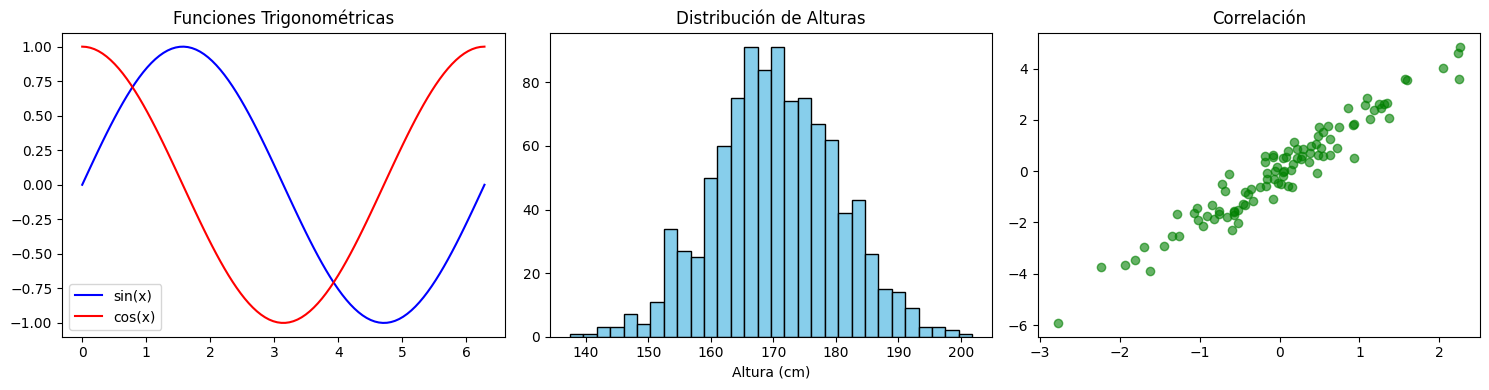

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Gráfico de línea
x = np.linspace(0, 2 * np.pi, 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Línea
axes[0].plot(x, np.sin(x), label="sin(x)", color="blue")
axes[0].plot(x, np.cos(x), label="cos(x)", color="red")
axes[0].set_title("Funciones Trigonométricas")
axes[0].legend()

# 2. Histograma
datos = np.random.normal(170, 10, 1000)  # Alturas simuladas
axes[1].hist(datos, bins=30, color="skyblue", edgecolor="black")
axes[1].set_title("Distribución de Alturas")
axes[1].set_xlabel("Altura (cm)")

# 3. Scatter
x_scatter = np.random.randn(100)
y_scatter = 2 * x_scatter + np.random.randn(100) * 0.5
axes[2].scatter(x_scatter, y_scatter, alpha=0.6, c="green")
axes[2].set_title("Correlación")

plt.tight_layout()
plt.show()

## Keras — Tu Primera Red Neuronal

**Keras** (integrada en TensorFlow) es la forma más accesible de construir redes neuronales en Python. Su filosofía es "diseñada para seres humanos, no para máquinas" — prioriza la claridad y la facilidad de uso sobre la flexibilidad absoluta.

Vamos a construir un clasificador de dígitos escritos a mano usando el dataset **MNIST**, que es el "Hola Mundo" del Deep Learning: un rito de paso por el que pasa todo el mundo en IA.

### ¿Qué es MNIST?

MNIST es un dataset de **70.000 imágenes** de dígitos escritos a mano (0-9), cada una de **28×28 píxeles** en escala de grises. Es tan ubicuo que la comunidad lo considera el benchmark más básico — si tu modelo no funciona con MNIST, hay un problema serio.

- **60.000 imágenes** para entrenamiento (learning)
- **10.000 imágenes** para test (evaluación)

### ¿Qué es una Red Neuronal?

Una red neuronal es un modelo matemático inspirado (vagamente) en el cerebro humano. Consiste en **capas de neuronas** conectadas entre sí, donde cada conexión tiene un **peso** que el modelo aprende a ajustar durante el entrenamiento:

```
┌─────────────┐     ┌──────────────┐     ┌──────────────┐     ┌──────────────┐
│   INPUT      │     │  CAPA OCULTA │     │  CAPA OCULTA │     │    OUTPUT    │
│   (784       │────▶│  (128        │────▶│  (64         │────▶│  (10 clases) │
│   píxeles)   │     │   neuronas)  │     │   neuronas)  │     │  0,1,...,9   │
└─────────────┘     └──────────────┘     └──────────────┘     └──────────────┘
  Imagen 28x28         ReLU                  ReLU                 Softmax
```

### Conceptos clave del flujo:

1. **Input (Flatten)**: la imagen de 28×28 píxeles se "aplana" a un vector de 784 valores (cada píxel es un número entre 0 y 1 que indica la intensidad de gris).
2. **Capas ocultas (Dense + ReLU)**: transforman los datos pasándolos por funciones matemáticas (pesos × inputs + sesgo), aplicando una activación no lineal (ReLU = max(0, x)).
3. **Dropout**: durante el entrenamiento, "apaga" aleatoriamente un porcentaje de neuronas para evitar el **sobreajuste** (overfitting) — que el modelo memorice los datos en vez de aprender patrones generales.
4. **Output (Softmax)**: la última capa tiene 10 neuronas (una por dígito) y devuelve **probabilidades** que suman 1. La neurona con mayor probabilidad es la predicción del modelo.

### El ciclo de entrenamiento

```
Por cada época (pasada completa por los datos):
  Por cada batch (grupo de imágenes):
    1. Forward pass: pasar imágenes por la red → obtener predicciones
    2. Calcular loss: comparar predicciones con las etiquetas reales
    3. Backward pass: calcular cuánto debe ajustarse cada peso
    4. Actualizar pesos: el optimizador (Adam) ajusta los pesos
```

> 🧠 **No necesitáis entender las matemáticas** detrás de cada paso en este módulo — eso lo veréis en las asignaturas de Deep Learning y ML Predictivo. Lo importante es entender el **flujo conceptual** y saber usar Keras para construir modelos.

In [ ]:
# Instalar TensorFlow (ya viene en Colab)
# !pip install tensorflow

import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. Cargar el dataset MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Normalizar los píxeles (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"Datos de entrenamiento: {x_train.shape}")  # (60000, 28, 28)
print(f"Datos de test: {x_test.shape}")              # (10000, 28, 28)
print(f"Ejemplo de etiqueta: {y_train[0]}")          # El dígito de la primera imagen

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos de entrenamiento: (60000, 28, 28)
Datos de test: (10000, 28, 28)
Ejemplo de etiqueta: 5


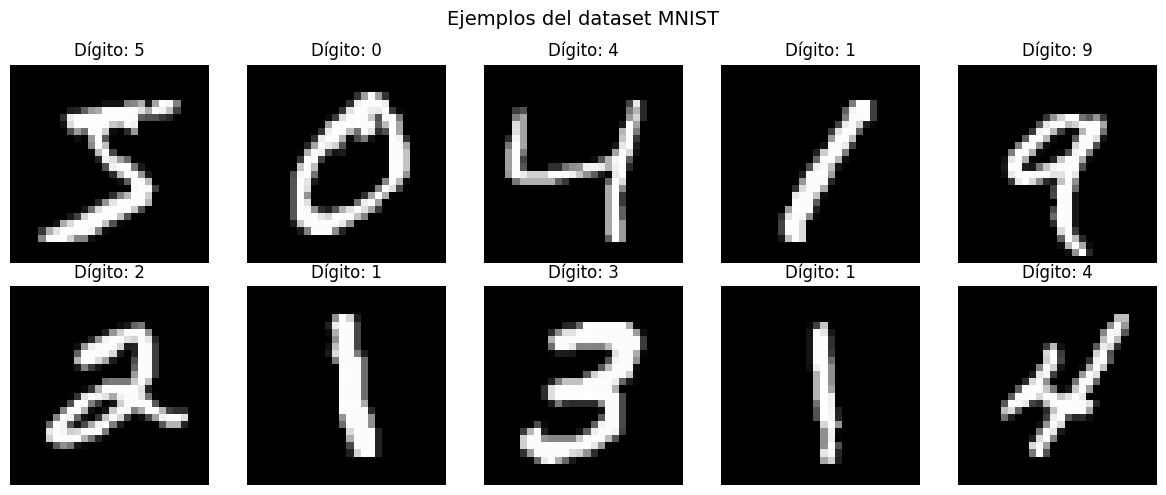

In [ ]:
# Visualizar algunas imágenes del dataset
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Dígito: {y_train[i]}")
    ax.axis("off")
plt.suptitle("Ejemplos del dataset MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Construir el modelo
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Aplanar 28×28 → 784
    keras.layers.Dense(128, activation="relu"),           # Capa oculta 1
    keras.layers.Dropout(0.2),                            # 20% dropout (evita overfitting)
    keras.layers.Dense(64, activation="relu"),            # Capa oculta 2
    keras.layers.Dense(10, activation="softmax")          # Salida: 10 clases
])

# 4. Compilar
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Ver la arquitectura
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 🛠️ Ejercicio — Modifica la Red Neuronal con Prompts

Pide a Gemini:

> *"Modifica la red neuronal anterior para que tenga 3 capas ocultas (256, 128, 64 neuronas), usa BatchNormalization después de cada capa, y entrena durante 10 épocas. Muestra una comparativa de accuracy antes y después."*

Pega el resultado aquí:

### Red Neuronal Modificada

Aquí está la red neuronal con las modificaciones solicitadas: tres capas ocultas con BatchNormalization y entrenamiento durante 10 épocas.

In [ ]:
# Pega aquí la red neuronal modificada por Gemini


In [ ]:
print('Accuracy del modelo anterior:', accuracy)

# 3. Construir el modelo modificado
model_modified = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Aplanar 28×28 → 784
    keras.layers.Dense(256),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),                       # Capa oculta 1
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),                       # Capa oculta 2
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),                       # Capa oculta 3
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')          # Salida: 10 clases
])

# 4. Compilar el modelo modificado
model_modified.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Ver la arquitectura del modelo modificado
model_modified.summary()

Accuracy del modelo anterior: 0.9745000004768372


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# 5. Entrenar el modelo modificado
print("Entrenando el modelo modificado...")
history_modified = model_modified.fit(
    x_train, y_train,
    epochs=10, # Aumentar a 10 épocas
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Entrenando el modelo modificado...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8816 - loss: 0.4240 - val_accuracy: 0.9618 - val_loss: 0.1220
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9486 - loss: 0.1748 - val_accuracy: 0.9732 - val_loss: 0.0863
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9604 - loss: 0.1322 - val_accuracy: 0.9783 - val_loss: 0.0766
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9669 - loss: 0.1091 - val_accuracy: 0.9773 - val_loss: 0.0728
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9711 - loss: 0.0924 - val_accuracy: 0.9810 - val_loss: 0.0661
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9737 - loss: 0.0867 - val_accuracy: 0.9813 - val_loss: 0.0659
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9762 - loss: 0.0742 - val_accuracy: 0.9825 - val_loss: 0.0615
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accurac

In [ ]:
# 6. Evaluar el modelo modificado en datos de test
loss_modified, accuracy_modified = model_modified.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy del modelo modificado en test: {accuracy_modified:.4f} ({accuracy_modified*100:.1f}%)\n")

# Comparativa de Accuracy
print("=== Comparativa de Accuracy ===")
print(f"Accuracy del modelo anterior: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Accuracy del modelo modificado: {accuracy_modified:.4f} ({accuracy_modified*100:.1f}%)")

Accuracy del modelo modificado en test: 0.9816 (98.2%)

=== Comparativa de Accuracy ===
Accuracy del modelo anterior: 0.9745 (97.5%)
Accuracy del modelo modificado: 0.9816 (98.2%)


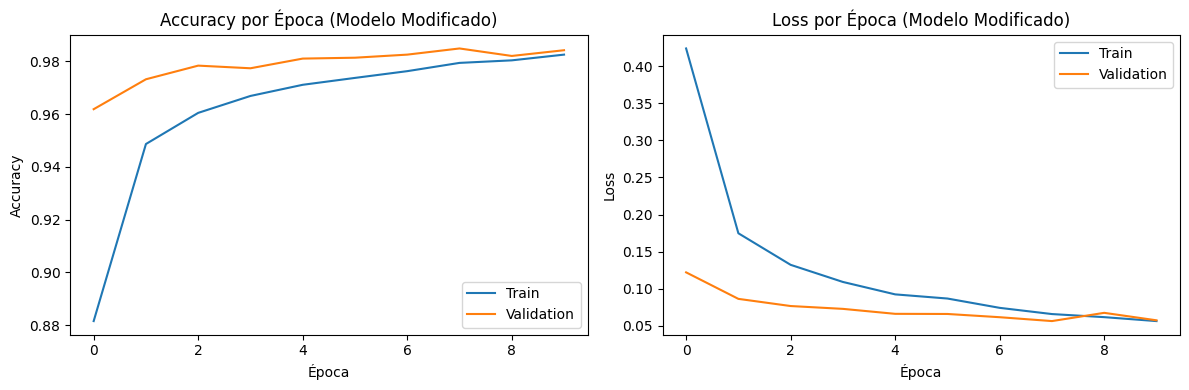

In [ ]:
# 7. Visualizar el entrenamiento del modelo modificado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_modified.history["accuracy"], label="Train")
ax1.plot(history_modified.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy por Época (Modelo Modificado)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history_modified.history["loss"], label="Train")
ax2.plot(history_modified.history["val_loss"], label="Validation")
ax2.set_title("Loss por Época (Modelo Modificado)")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 5. Entrenar
print("Entrenando...")
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 6. Evaluar en datos de test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy:.4f} ({accuracy*100:.1f}%)")

Entrenando...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8807 - loss: 0.4043 - val_accuracy: 0.9595 - val_loss: 0.1454
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9467 - loss: 0.1794 - val_accuracy: 0.9710 - val_loss: 0.1064
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9595 - loss: 0.1325 - val_accuracy: 0.9743 - val_loss: 0.0855
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9672 - loss: 0.1073 - val_accuracy: 0.9768 - val_loss: 0.0783
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9715 - loss: 0.0909 - val_accuracy: 0.9783 - val_loss: 0.0738
Accuracy en test: 0.9745 (97.5%)


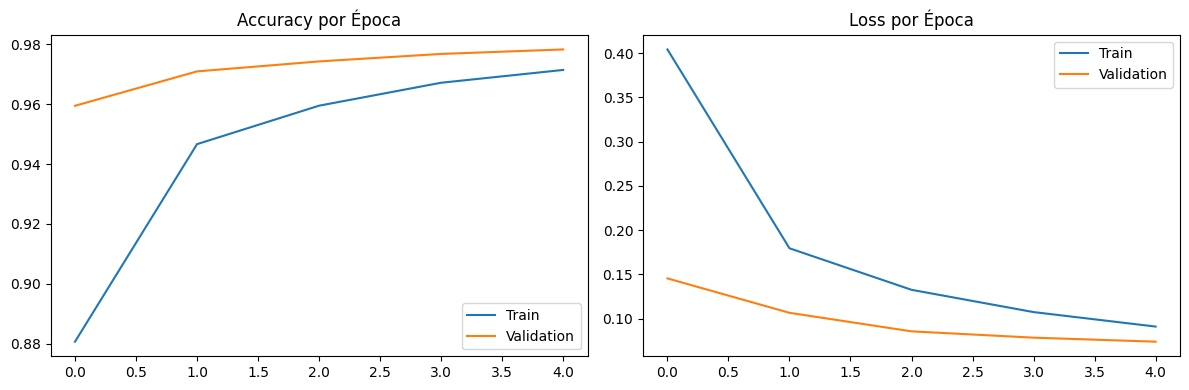

In [ ]:
# 7. Visualizar el entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy por Época")
ax1.legend()

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss por Época")
ax2.legend()

plt.tight_layout()
plt.show()

---
# 🎮 Kahoot — Repaso de la Sesión 2

¡Vamos a repasar lo aprendido!

**Temas cubiertos:**
- NumPy y Pandas
- Técnicas de prompting (Chain of Thought, Role Prompting, Few-shot)
- Desarrollo agéntico y GitHub Copilot
- Redes neuronales con Keras

> El link del Kahoot se compartirá durante la clase en directo.

---
## 📚 Recursos adicionales

- [NumPy — Guía para principiantes](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [Pandas — 10 minutos para empezar](https://pandas.pydata.org/docs/user_guide/10min.html)
- [Prompt Engineering Guide](https://www.promptingguide.ai/)
- [GitHub Student Developer Pack](https://education.github.com/pack)
- [GitHub Copilot Docs](https://docs.github.com/en/copilot)
- [Keras — Tutorial oficial](https://keras.io/getting_started/)
- [MNIST Dataset](http://yann.lecun.com/exdb/mnist/)

## ⏭️ Próxima sesión

**Sesión 3: Ecosistema IA — HuggingFace, LangChain y Modelos**
- HuggingFace: Model Hub, Pipeline API, Datasets
- APIs de LLMs: consumir Gemini, OpenAI, Anthropic desde Python
- LangChain y RAG: construir un sistema de pregunta-respuesta sobre documentos
- Demo: modelos locales con Ollama